# Lesson 185 · Causal & relational data

**Tier C: original synthetic mechanism experiment.** Full five-seed run; no paper benchmark. Read → predict → implement → compare → defend. Author-reference tables below are saved evidence, not your kernel output. No network, cloud or dataset download is required.

First recall: why does a company-level split matter? Why does a legal feature not necessarily make a useful action?

This self-contained notebook embeds all source and figures. CPU only; Python 3 with NumPy, pandas and scikit-learn. The exact author environment is listed below. Colab is unverified; portable images are embedded as PNG data URLs.

Author versions: Python 3.12.3; numpy 2.5.0, pandas 3.0.3, scikit-learn 1.9.0, pyarrow 24.0.0, nbformat 5.10.4, nbclient 0.11.0, nbconvert 7.17.1, matplotlib 3.11.0. For exact parity use the pinned requirements linked in the protocol. No installation cell runs automatically.

In [1]:
# @colab-bootstrap — standalone, no clone or installation needed if dependencies are present.
import json
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
SEEDS = tuple(range(5))
print("Original synthetic experiment; 5 seeds; cloud/API $0")

Original synthetic experiment; 5 seeds; cloud/API $0


**Your win:** explain why a predictor can rank customers correctly yet recommend an ineffective action. Then implement the intervention that proves the distinction in a fully specified simulator.

**Observed evidence:** all five seeds of the approved original synthetic experiment completed. This is a complete teaching experiment, not a published-paper benchmark reproduction. Learner defense remains **PENDING_WRITTEN_DEFENSE**.

<div class="lab-links"><a href="https://avistian.github.io/relational/labs/0185-causal-relational-data.ipynb">Start the student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0185-causal-relational-data.html">Read the executed solution</a> · <a href="https://avistian.github.io/relational/labs/solutions/0185-causal-relational-data.ipynb">Download the solution</a> · <a href="https://avistian.github.io/relational/reference/causal-relational-data.html">Printable reference</a> · <a href="https://avistian.github.io/relational/labs/l185-reproduction.md">Reproduce all five seeds</a></div>

## 1 · A leaderboard answers only the first question

The frontier sequence explores better ways to predict from relational data. This lesson changes the question: **what should we change to improve an outcome?** It does not require you to have completed the intervening model lessons. [Lesson 184](0184-gelgt-temporal-attention.html) separated legal context from learned attention. Even if both are correct, a prediction need not identify an effective action. Recall [Lesson 181](https://avistian.github.io/relational/lessons/0181-relbench-v2-autocomplete.html): a trustworthy score needs a legal information set and a clearly identified query. Here those checks pass, yet a proposed action still fails.

A sales manager sees that customers at badged companies buy more often. A badge-only predictor ranks them well, even on companies withheld from training. The manager proposes giving every company a badge. Should purchases rise?

**Prediction** estimates an outcome under a data-generating process. **Intervention** changes part of that process. A feature can be useful for the first without being a useful lever for the second. Pearl formalizes this distinction by replacing a variable's generating rule while retaining the remaining rules. [Primary reading: Pearl (2009), §§2 and 3.2.1](https://ftp.cs.ucla.edu/pub/stat_ser/r350.pdf).



## 2 · Follow the company relationship

A **structural causal model**, abbreviated SCM, declares how variables generate one another. Its arrows encode assumptions about causes. They are not arrows inferred from a foreign-key join or from predictive importance.

Our SCM has four variables. **U** is company demand: 0 means low and 1 means high. Despite the letter U, demand is **observed** in this experiment. **B** is the company's badge. **A** is a customer service action. **Y** is a later purchase, coded 0 or 1. Each company has twenty customers. Their shared demand and badge create dependence across rows.

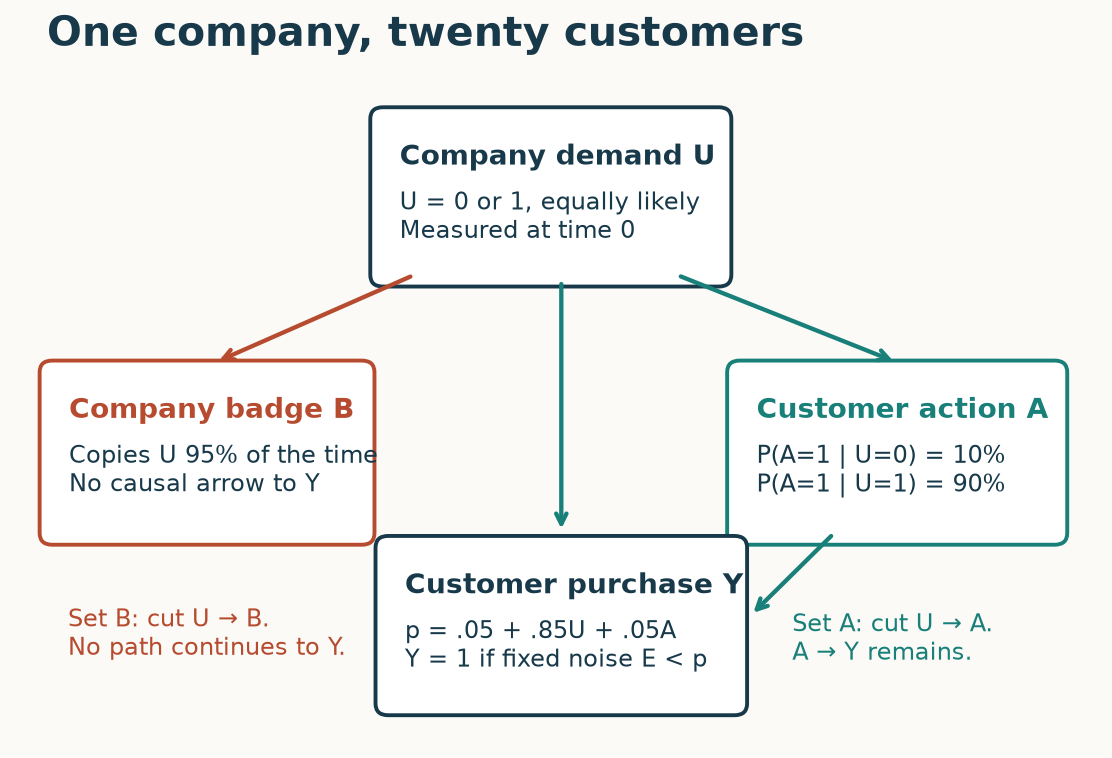

*Declared causal graph. Company U and B are shared by twenty customers; A and Y belong to individual customers. Arrows are causal assumptions, not foreign keys. Cutting the badge assignment leaves no causal path from B to Y.*

**Database structure.** `companies(company_id, U, B, available_at)` joins to `customers(customer_id, company_id, cutoff, split)`. Customer IDs join to `actions(customer_id, A, action_at)` and `outcomes(customer_id, Y, E, outcome_at)`. A **primary key** uniquely names a row; a **foreign key** refers to a row in another table. The prediction query is `(customer_id, cutoff)`.

All company features arrive at time 0. Actions occur at time 1, when prediction is made. Purchases occur at time 2. The outcome table also stores **E**, a random threshold used only by the evaluator. Predictors may see B, A, or (U,A); they never see E, Y, or future fields. The action-only predictor is therefore an after-action forecast, not a pre-action decision rule.

**The precise generating rules.** A Bernoulli draw produces 1 with its stated probability. Company demand is Bernoulli(0.5). The badge equals demand with probability 0.95. Action probability is 0.1 for low-demand companies and 0.9 for high-demand companies. Customer thresholds E are independent uniform draws between 0 and 1. Purchase probability is:

`p = 0.05 + 0.85 × U + 0.05 × A`, followed by `Y = 1 if E < p, otherwise 0`.

These constants are our teaching choices. They do not come from an empirical sales study. B is deliberately absent from the purchase equation. No customer's action changes another customer's outcome in this baseline.

> **In plain terms.** The badge usually tells you which companies already have demand. Printing a new badge does not create that demand.

## 3 · Observe a badge, or assign one?

**Conditioning** selects cases with an observed value. Among companies already carrying a badge, high demand is common. **Doing**, written `do(B=1)`, assigns that value regardless of the old rule. It does not select a high-demand population. This is the distinction pictured by cutting the incoming arrow to the assigned variable. [Pearl, §3.2.1](https://ftp.cs.ucla.edu/pub/stat_ser/r350.pdf).



**Pause and predict:** will assigning badges change purchases in the declared graph?

**Worked example.** In the exact balanced population, purchase probability is 90.05% among observed badged companies and 9.95% among unbadged companies. But forcing all badges to 1 leaves purchase probability at 50%. Forcing all badges to 0 also leaves it at 50%. Observing B changes what we know about U; assigning B does not change U.


<p><strong>Static intervention reference:</strong> observed purchase probability 50%; do(B=0) and do(B=1): 50%; do(A=0): 47.5%; do(A=1): 52.5%. All values use the exact 50/50 demand population.</p>

**Hold randomness fixed.** A **potential outcome** is the purchase a particular customer would have under a specified action. Run the same customer twice with the same U and E, replacing only A. This isolates the effect in the simulator. For U=0 and E=0.075, no action gives p=0.05 and Y=0; action gives p=0.10 and Y=1. Changing only B leaves p unchanged. Real observational data do not supply both potential outcomes for the same customer. [Pearl, §3.4](https://ftp.cs.ucla.edu/pub/stat_ser/r350.pdf).

## 4 · Why the observed action gap is too large

A **confounder** is a common cause of action and outcome. Demand is one here: high-demand customers receive more actions and buy more anyway. The path `A ← U → Y` mixes those differences into the observed action comparison.

**Worked example.** Among customers with A=1, 90% have high demand. Their purchase rate is `0.9 × 0.95 + 0.1 × 0.10 = 0.865`. Among A=0 customers, only 10% have high demand. Their rate is `0.1 × 0.90 + 0.9 × 0.05 = 0.135`. Subtraction gives **73 percentage points**, although the action adds only **5 points** within either demand group.

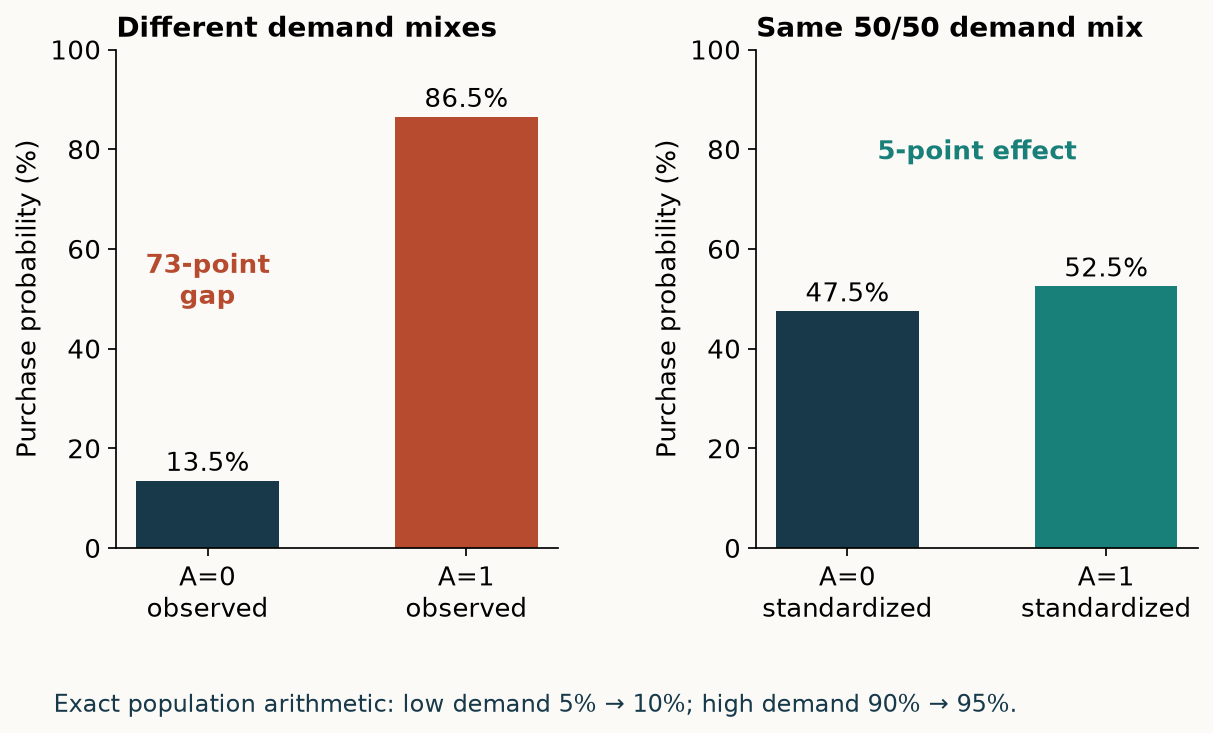

*Exact population illustration, not measured sample means. Standardization holds the demand mix at 50/50: .5 × (.10 − .05) + .5 × (.95 − .90) = .05.*

**Standardization** compares both action states under the same demand composition. Within low demand, the difference is `0.10 − 0.05 = 0.05`. Within high demand, it is `0.95 − 0.90 = 0.05`. Weighting both differences by the population's demand proportions gives 0.05. In a finite dataset, the notebook estimates those group means and weights from the held-out population. This estimates its average treatment effect, abbreviated **ATE**. [Adjustment principle: Pearl, §§3.2.3 and 3.3.1](https://ftp.cs.ucla.edu/pub/stat_ser/r350.pdf).

This works here because we declared the full causal mechanism. For a real application, defend the following assumptions before interpreting an adjusted comparison causally:

- **Sufficient adjustment:** no remaining common cause of A and Y after accounting for U.
- **Overlap:** each demand group can receive either action. Here those probabilities are 0.1 and 0.9, both strictly between zero and one.
- **Well-defined action:** setting A means the same intervention across the comparison.
- **No interference in this baseline:** one customer's action does not change another customer's purchase.

A join can recover a relevant company variable. It cannot establish these assumptions. If colleagues influence each other, an intervention must also specify who else receives it. Relational causal discovery is a separate research topic; [Maier et al. (2013)](https://arxiv.org/abs/1309.6843v1) introduce an algorithm for that problem. This lab assumes its graph and does not reproduce their algorithm or results.

## 5 · Full experiment: every seed, every customer

**Held fixed:** the four generating rules, 1,000 companies, twenty customers each, three predictor recipes, and company-disjoint 60/20/20 splits. Independent random streams determine company traits, actions, outcomes, and splits. **Varied:** seeds 0–4 and the declared intervention. **Measured:** held-out ranking, observed association, adjusted effect, and paired potential-outcome differences.

Each predictor is a transparent conditional-frequency table fitted only on training labels. Badge-only learns two purchase rates; action-only learns two; demand-plus-action learns four. An unseen combination falls back to the global training purchase rate. No model is selected using validation or test. Both splits are scored for all three recipes. The causal audit uses test outcomes to estimate effects, separately from fitting the predictive models.

**AUROC** is the probability that a randomly selected purchaser receives a higher score than a nonpurchaser, with half credit for a tie. A score of 0.5 is chance ranking; 1 is perfect. It says nothing by itself about the effect of changing a score input.

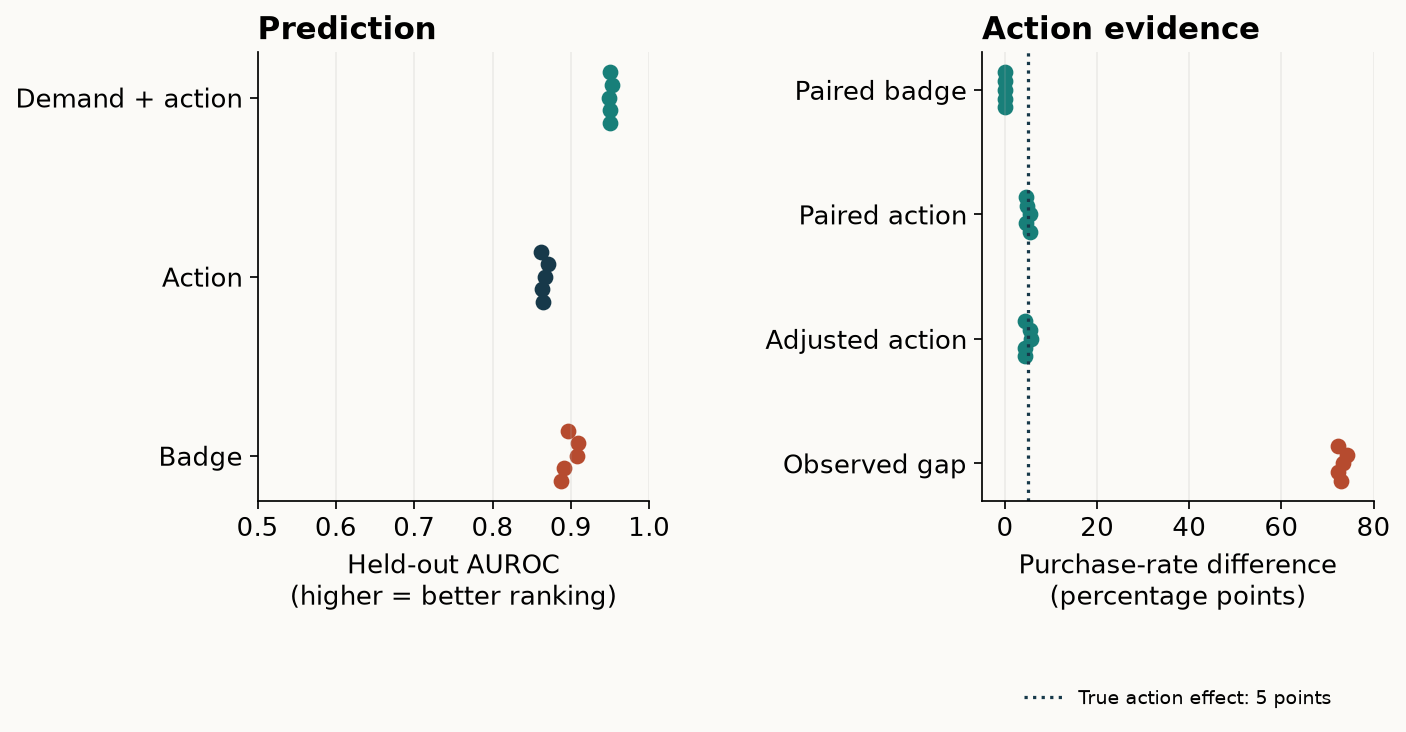

*Measured synthetic evidence. Each dot is one of seeds 0–4. Ranking and action effects have different units; a strong AUROC is not an intervention effect. The dotted line marks the known 5-point action effect.*

| Quantity | Mean ± seed SD |
|---|---:|
| Badge-only test AUROC | 0.8986 ± 0.0097 |
| Action-only test AUROC | 0.8653 ± 0.0037 |
| Demand + action test AUROC | 0.9503 ± 0.0013 |
| Observed action gap (points) | 73.0164 ± 0.8386 |
| Adjusted action effect (points) | 4.8060 ± 0.7057 |
| Paired action effect (points) | 4.9150 ± 0.4141 |
| Paired badge effect (points) | 0.0000 ± 0.0000 |

The table gives **mean ± sample standard deviation across five independently generated seeds**. These spreads are not confidence intervals based on 20,000 independent customers: customers share companies. The five seeds are replications of one declared simulator, not five independent real datasets.

| Seed | Badge AUROC | Observed action gap (points) | Adjusted effect (points) | Paired effect (points) |
|---|---:|---:|---:|---:|
| 0 | 0.8877 | 72.885 | 4.281 | 5.325 |
| 1 | 0.8915 | 72.200 | 4.322 | 4.525 |
| 2 | 0.9082 | 73.394 | 5.677 | 5.400 |
| 3 | 0.9090 | 74.256 | 5.473 | 4.700 |
| 4 | 0.8967 | 72.346 | 4.278 | 4.625 |

**A policy has a different baseline.** Setting A=1 for everyone adds **2.41 percentage points** relative to the observed assignments. This is smaller than the 5-point ATE because some customers already receive A. Setting B=1 adds exactly zero. These are purchase-rate gains; costs, capacity, and profit are not modeled, so we do not claim an optimal deployment policy.

The audit independently recomputed **120,000 prediction scores** across all validation/test/model/seed combinations and checked **20,000 paired test customers**. A fresh complete run reproduced every saved table and report exactly in the captured environment. See the [audit](https://avistian.github.io/relational/labs/_verify_l185_results.json), [measured report](https://avistian.github.io/relational/labs/evidence/l185/report.json), and [budget ledger](https://avistian.github.io/relational/labs/evidence/l185/budget.json).

## 6 · Implement, predict, defend

Open the [student notebook](https://avistian.github.io/relational/labs/0185-causal-relational-data.ipynb). Its three live tasks feed the full five-seed run:

1. **Join safely.** Preserve one row per customer/cutoff, reject missing or duplicated relationships, and enforce time and split boundaries.
2. **Intervene.** Replace the assigned mechanism and reuse the customer's random threshold without mutating the original rows.
3. **Adjust.** Compare action groups within demand strata and standardize; refuse an estimate when treatment overlap is absent.

Each task has an immediate CHECK. The provided cells expose the generator, predictor, evaluation, and aggregation. Predict the direction of each result before running the final experiment. Then submit your report and a short defense: “What evidence would make assigning badges a defensible real-world strategy?”



**Exit gate.** Successful code establishes that you can execute this experiment. Your explanation must distinguish prediction, observation, intervention, and policy value. A prepared solution is not evidence of your mastery. Ask the teacher about any unclear step, and return in a few days to explain the badge example without looking at the diagram.

**Reading and next connection.** Read Pearl §§2 and 3.2.1 first; then §3.3.1 for adjustment. [Lesson 186](0186-production-constraints.html) asks whether a justified strategy can also meet serving and freshness requirements. The later research proposal must defend both its predictive claim and its decision claim.

> **Evidence boundary.** Complete original synthetic experiment; published-paper reproduction and real-world causal effectiveness **NOT_ESTABLISHED**. Live Colab and deployment **NOT_CHECKED**. No earlier lesson's completion gate is changed.


In [2]:
import unittest
class CausalContracts(unittest.TestCase):
 def test_do_replaces_action_and_reuses_noise(self):
  f=pd.DataFrame({'U':[0,0,1,1],'B':[0,1,0,1],'A':[0,1,0,1],'E':[.075,.075,.925,.925]})
  before=f.copy(deep=True)
  np.testing.assert_array_equal(intervene(f,action=0),[0,0,0,0])
  np.testing.assert_array_equal(intervene(f,action=1),[1,1,1,1])
  np.testing.assert_array_equal(intervene(f,badge=0),intervene(f,badge=1))
  pd.testing.assert_frame_equal(f,before)
 def test_adjustment_removes_composition_effect(self):
  rows=[]
  # Exact risk differences .2 in both strata; biased treatment allocation.
  for u,a,n,positive in [(0,0,80,8),(0,1,20,6),(1,0,20,12),(1,1,80,64)]:
   rows += [{'U':u,'A':a,'Y':int(i<positive)} for i in range(n)]
  f=pd.DataFrame(rows)
  self.assertAlmostEqual(adjusted_effect(f),.2)
  with self.assertRaises(ValueError):adjusted_effect(f[~((f.U==0)&(f.A==1))])
 def test_duplicate_and_missing_relationships_rejected(self):
  t={'companies':pd.DataFrame({'company_id':[0],'U':[1],'B':[1],'available_at':[0]}),
     'customers':pd.DataFrame({'customer_id':[3],'company_id':[0],'cutoff':[1],'split':['test']}),
     'actions':pd.DataFrame({'customer_id':[3],'A':[0],'action_at':[1]}),
     'outcomes':pd.DataFrame({'customer_id':[3],'Y':[1],'outcome_at':[2],'E':[.3]})}
  self.assertEqual(len(assemble(t)),1)
  for key in t:
   bad={k:v.copy() for k,v in t.items()};bad[key]=pd.concat([bad[key],bad[key]])
   with self.assertRaises(ValueError):assemble(bad)
  bad={k:v.copy() for k,v in t.items()};bad['actions']=bad['actions'].iloc[:0]
  with self.assertRaises(ValueError):assemble(bad)
  bad={k:v.copy() for k,v in t.items()};bad['companies']['available_at']=2
  with self.assertRaises(ValueError):assemble(bad)

## TODO · Task 1 · Preserve the relational query

Implement the complete-key and time-safe assembly contract. Reject duplicated primary keys, missing/extra action or outcome rows, unknown companies, invalid availability, and companies split across groups. Return rows sorted by customer_id and cutoff. The input is a dictionary of the four DataFrames described above.

**Why this matters:** this function is called by the complete experiment below. The CHECK uses a small hand-computable counterexample, not your final score.

In [3]:
def assemble(tables):
    """Validate keys, join at customer grain, and enforce the availability contract."""
    c, q, a, y = (tables[k].copy() for k in ('companies','customers','actions','outcomes'))
    for table, key in ((c,'company_id'),(q,'customer_id'),(a,'customer_id'),(y,'customer_id')):
        if table[key].isna().any() or table[key].duplicated().any():
            raise ValueError('Null or duplicate primary key')
    ids = set(q.customer_id)
    if set(a.customer_id) != ids or set(y.customer_id) != ids:
        raise ValueError('Missing or extra action/outcome identity')
    if not set(q.company_id).issubset(set(c.company_id)):
        raise ValueError('Missing company foreign key')
    f = q.merge(c,on='company_id',validate='many_to_one').merge(a,on='customer_id',validate='one_to_one').merge(y,on='customer_id',validate='one_to_one')
    if not ((f.available_at <= f.cutoff) & (f.action_at <= f.cutoff) & (f.outcome_at > f.cutoff)).all():
        raise ValueError('Feature/action availability or outcome horizon violated')
    if f.groupby('company_id')['split'].nunique().max() != 1:
        raise ValueError('Company leaks across splits')
    if f[['customer_id','cutoff']].duplicated().any():
        raise ValueError('Duplicate query identity')
    return f.sort_values(['customer_id','cutoff']).reset_index(drop=True)

In [4]:
CausalContracts().test_duplicate_and_missing_relationships_rejected()
print("CHECK passed: assemble")

CHECK passed: assemble


## TODO · Task 2 · Change a mechanism

Return a NumPy integer outcome array in input order. Accept None, 0 or 1 for badge/action. Replace only requested assignments, retain underlying U and E, and leave input rows unchanged. Explain why badge is not a parent of Y before coding.

**Why this matters:** this function is called by the complete experiment below. The CHECK uses a small hand-computable counterexample, not your final score.

In [5]:
def intervene(frame, badge=None, action=None):
    """Replace a mechanism, reuse E, and return potential outcomes in input order."""
    if badge not in (None, 0, 1) or action not in (None, 0, 1):
        raise ValueError('Interventions must be binary')
    changed = frame.copy()
    if badge is not None:
        changed['B'] = badge
    if action is not None:
        changed['A'] = action
    # B has no arrow to Y in this declared SCM. Setting B never changes U or A.
    probability = .05 + .85 * changed['U'] + .05 * changed['A']
    return (changed['E'].to_numpy() < probability.to_numpy()).astype(np.int64)

In [6]:
CausalContracts().test_do_replaces_action_and_reuses_noise()
print("CHECK passed: intervene")

CHECK passed: intervene


## TODO · Task 3 · Compare like with like

Return the demand-standardized action risk difference as a float, using this frame’s demand proportions. Reject missing action overlap in any observed demand stratum. Inputs contain U, A and Y.

**Why this matters:** this function is called by the complete experiment below. The CHECK uses a small hand-computable counterexample, not your final score.

In [7]:
def adjusted_effect(frame):
    """Standardize action risk differences over this population's demand mix."""
    means = frame.groupby(['U', 'A'])['Y'].mean()
    weights = frame['U'].value_counts(normalize=True)
    total = 0.0
    for u, weight in weights.items():
        if (u, 0) not in means or (u, 1) not in means:
            raise ValueError('No treatment overlap within a demand stratum')
        total += weight * (means.loc[(u, 1)] - means.loc[(u, 0)])
    return float(total)

In [8]:
CausalContracts().test_adjustment_removes_composition_effect()
print("CHECK passed: adjusted_effect")

CHECK passed: adjusted_effect


## PROVIDED · Generate the normalized database

Four independent random streams separate company traits, assignments, customer thresholds and group splitting. This code calls your intervention to generate observed Y. The company ID carries the shared U/B values into the customer rows; it is not used as a predictor.

In [9]:
def generate(seed):
    """Independent streams for company traits, assignment, outcomes, and split."""
    traits, assign, outcome, splitter = [np.random.default_rng(s) for s in np.random.SeedSequence(seed).spawn(4)]
    u = traits.binomial(1,.5,1000)
    b = u ^ traits.binomial(1,.05,1000)
    order = splitter.permutation(1000)
    split = np.empty(1000,dtype=object)
    split[order[:600]], split[order[600:800]], split[order[800:]] = 'train','validation','test'
    company = np.repeat(np.arange(1000),20)
    customer = np.arange(20000)
    action = assign.binomial(1,.1+.8*u[company])
    noise = outcome.random(20000)
    frame = pd.DataFrame({'U':u[company],'B':b[company],'A':action,'E':noise})
    return {
        'companies':pd.DataFrame({'company_id':np.arange(1000),'U':u,'B':b,'available_at':0}),
        'customers':pd.DataFrame({'customer_id':customer,'company_id':company,'cutoff':1,'split':split[company]}),
        'actions':pd.DataFrame({'customer_id':customer,'A':action,'action_at':1}),
        'outcomes':pd.DataFrame({'customer_id':customer,'Y':intervene(frame),'E':noise,'outcome_at':2})}

## PROVIDED · Fit transparent probability tables

This is the entire predictive model: count outcomes within each permitted feature combination, using training data only. There is no optimizer or checkpoint. Predicting an outcome from A is distinct from choosing A to improve that outcome.

In [10]:
def predict_frequency(train, query, columns):
    """Training labels only; global training mean if a combination is unseen."""
    if set(columns) - {'U','B','A'}:
        raise ValueError('Illegal predictor column')
    if not (train['split']=='train').all():
        raise ValueError('Fitting is restricted to training rows')
    means = train.groupby(columns)['Y'].mean().rename('score').reset_index()
    return query[columns].merge(means,on=columns,how='left',validate='many_to_one',sort=False)['score'].fillna(train.Y.mean()).to_numpy()

## PROVIDED · Score one seed

Follow validation/test query keys into each predictor. Then follow the test customers into four paired interventions. The adjusted estimate is calculated from held-out observations; E is used only for simulator truth. **Predict first:** which is closer to 5 percentage points, the observed action gap or the adjusted effect?

In [11]:
def run_seed(seed):
    tables = generate(seed)
    f = assemble(tables)
    train = f[f.split=='train']
    test = f[f.split=='test'].copy()
    prediction_parts, metrics = [], {'seed':int(seed)}
    for split in ('validation','test'):
        q = f[f.split==split]
        for name, columns in [('badge',['B']),('action',['A']),('demand_action',['U','A'])]:
            score = predict_frequency(train,q,columns)
            part = q[['customer_id','cutoff','Y']].copy()
            part['split'],part['model'],part['score'] = split,name,score
            prediction_parts.append(part)
            metrics[split+'_'+name+'_auroc'] = float(roc_auc_score(q.Y,score))
    potentials = test[['customer_id','cutoff','company_id','U','B','A','Y','E']].copy()
    for name,kwargs in [('badge0',{'badge':0}),('badge1',{'badge':1}),('action0',{'action':0}),('action1',{'action':1})]:
        potentials[name] = intervene(test,**kwargs)
    association = test.groupby('A').Y.mean()
    metrics.update({
        'naive_action_difference':float(association.loc[1]-association.loc[0]),
        'adjusted_action_effect':adjusted_effect(test),
        'paired_action_effect':float((potentials.action1-potentials.action0).mean()),
        'paired_badge_effect':float((potentials.badge1-potentials.badge0).mean()),
        'expected_action_effect':.05,'expected_badge_effect':0.0,
        'observed_purchase_rate':float(test.Y.mean()),
        'badge1_policy_gain':float((potentials.badge1-potentials.Y).mean()),
        'action1_policy_gain':float((potentials.action1-potentials.Y).mean()),
        'expected_action1_policy_gain':float((.05*(1-test.A)).mean()),
        'train_rows':len(train),'validation_rows':int((f.split=='validation').sum()),'test_rows':len(test)})
    return tables,pd.concat(prediction_parts,ignore_index=True),potentials,metrics

## PROVIDED · Aggregate the full experiment

All five seeds are mandatory. Standard deviation describes variation across complete simulated datasets. It does not turn shared company rows into independent observations.

In [12]:
def full_experiment():
    """The entire approved experiment, without data-size or seed shortcuts."""
    outputs = [run_seed(seed) for seed in SEEDS]
    rows = [x[3] for x in outputs]
    keys = [k for k,v in rows[0].items() if isinstance(v,float)]
    summary = {k:{'mean':float(np.mean([r[k] for r in rows])),
                  'sd_across_seeds':float(np.std([r[k] for r in rows],ddof=1))} for k in keys}
    report = {'experiment':'L185 relational-shortcut-intervention-v1','status':'COMPLETE_SYNTHETIC_EXPERIMENT',
              'seeds':list(SEEDS),'rows_per_seed':20000,'per_seed':rows,'summary':summary,
              'paper_reproduction':'NOT_ESTABLISHED','real_world_causality':'NOT_ESTABLISHED',
              'learner':'PENDING_WRITTEN_DEFENSE','cloud_usd':0}
    return outputs,report

## RUN · Full approved experiment

No smaller preset is substituted. Save the report generated by your own functions and compare it with the author-reference evidence.

In [13]:
outputs, report = full_experiment()
Path("l185-report.json").write_text(json.dumps(report, indent=2)+"\n")
columns = ["seed", "test_badge_auroc", "naive_action_difference", "adjusted_action_effect", "paired_action_effect", "paired_badge_effect"]
display(pd.DataFrame(report["per_seed"])[columns])

,seed,test_badge_auroc,naive_action_difference,adjusted_action_effect,paired_action_effect,paired_badge_effect
0,0,0.887726,0.728851,0.042807,0.05325,0.0
1,1,0.891542,0.721998,0.043217,0.04525,0.0
2,2,0.908194,0.733944,0.056770,0.05400,0.0
3,3,0.909037,0.742562,0.054726,0.04700,0.0
4,4,0.896728,0.723465,0.042782,0.04625,0.0


In [14]:
assert report["seeds"] == [0,1,2,3,4]
for row in report["per_seed"]:
    assert row["paired_badge_effect"] == 0
    assert abs(row["paired_action_effect"]-.05) < .025
    assert abs(row["adjusted_action_effect"]-.05) < .025
print("CHECK: all five seeds and causal bounds passed")

CHECK: all five seeds and causal bounds passed


## EXIT TICKET · Defend the strategy

Explain, without quoting the lesson: (1) why high badge AUROC and zero badge effect can coexist; (2) why the observed action gap is confounded; (3) why all-treated policy gain is smaller than ATE; (4) how spillovers would change the experiment; (5) what real-world evidence is missing. Paste your explanation and table into the teaching chat.

These assertions cannot grade your explanation. Learner status stays PENDING_WRITTEN_DEFENSE. There is no unrun paper-results lane hidden behind this experiment: the approved unit is synthetic. A real causal benchmark would require a separately specified task and protocol.

In [15]:
submission = {"experiment": report["experiment"], "execution": report["status"], "learner": "PENDING_WRITTEN_DEFENSE", "paper_reproduction": "NOT_ESTABLISHED"}
Path("l185-submission.json").write_text(json.dumps(submission, indent=2)+"\n")
print(submission)

{'experiment': 'L185 relational-shortcut-intervention-v1', 'execution': 'COMPLETE_SYNTHETIC_EXPERIMENT', 'learner': 'PENDING_WRITTEN_DEFENSE', 'paper_reproduction': 'NOT_ESTABLISHED'}
